# Latent ODE vs RNN on 2D Spirals

This notebook reproduces the spiral benchmark from Neural ODE (Section 5.1).

Models:
- GRU baseline
- GRU + time-concat baseline
- Latent ODE (VAE)

Data:
- 1000 Archimedean spirals (CW/CCW)
- 500 time points per trajectory (clean ground truth)
- Noisy irregular observations with `nsample in {30, 50, 100}`


In [1]:
from pathlib import Path
import sys
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

root = Path.cwd()
if not (root / 'asa_ode').exists() and (root.parent / 'asa_ode').exists():
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from asa_ode.data import generate_spiral2d
from asa_ode.models import GRUBaseline, LatentODEVAE
from asa_ode.training import (
    prepare_spiral_batch,
    train_latent_ode_fullbatch,
    train_rnn_fullbatch,
)


/Users/andrew/miniconda3/envs/py3.11_asa_ode/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', device)

NSPIRAL = 1000
NTOTAL = 500
START = 0.0
STOP = 6.0 * np.pi
NOISE_STD = 0.1
A = 0.0
B = 0.3

LR = 1e-2
N_ITERS_MAIN = 2000
N_ITERS_SWEEP = 2000
EVAL_EVERY = 50
KL_ANNEAL_ITERS = 500
GRAD_CLIP = 1.0

USE_ADJOINT = True
if device.type == 'mps':
    USE_ADJOINT = False

print('use_adjoint:', USE_ADJOINT)


device: mps
use_adjoint: False


In [3]:
def make_spiral_data(nsample: int, seed: int) -> tuple:
    raw = generate_spiral2d(
        nspiral=NSPIRAL,
        ntotal=NTOTAL,
        nsample=nsample,
        start=START,
        stop=STOP,
        noise_std=NOISE_STD,
        a=A,
        b=B,
        seed=seed,
        shared_time_grid=True,
        shuffle_directions=True,
    )
    batch = prepare_spiral_batch(raw, device=device)
    return raw, batch

raw50, batch50 = make_spiral_data(nsample=50, seed=SEED)
print('orig:', raw50.orig_trajs.shape, 'sampled:', raw50.samp_trajs.shape)


orig: torch.Size([1000, 500, 2]) sampled: torch.Size([1000, 50, 2])


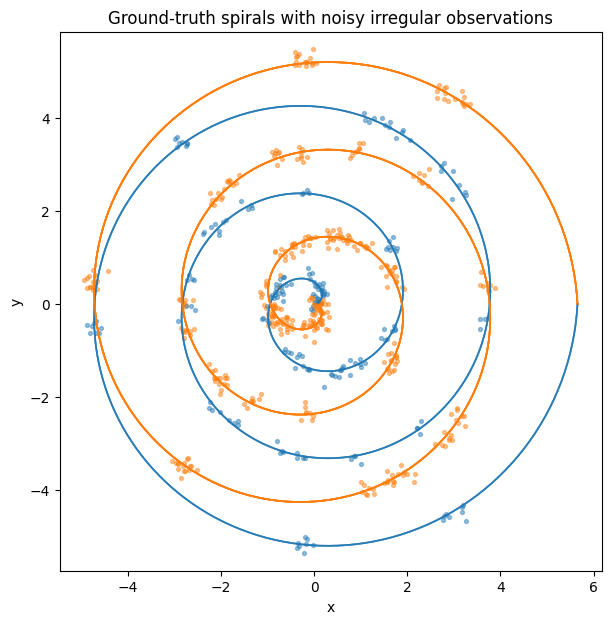

In [4]:
def plot_ground_truth(raw, n_examples: int = 10) -> None:
    idx = torch.randperm(raw.orig_trajs.shape[0])[:n_examples]
    plt.figure(figsize=(7, 7))
    for i in idx:
        i = int(i.item())
        traj = raw.orig_trajs[i].cpu().numpy()
        obs = raw.samp_trajs[i].cpu().numpy()
        color = 'tab:blue' if int(raw.direction[i].item()) == 1 else 'tab:orange'
        plt.plot(traj[:, 0], traj[:, 1], color=color, alpha=0.55, linewidth=1.2)
        plt.scatter(obs[:, 0], obs[:, 1], color=color, s=8, alpha=0.45)
    plt.title('Ground-truth spirals with noisy irregular observations')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.axis('equal')
    plt.show()

plot_ground_truth(raw50, n_examples=12)


In [5]:
def train_all_models(batch, n_iters: int, lr: float, eval_every: int, kl_anneal_iters: int, grad_clip: float):
    rnn = GRUBaseline(obs_dim=2, hidden_dim=25, use_time_concat=False).to(device)
    rnn_time = GRUBaseline(obs_dim=2, hidden_dim=25, use_time_concat=True).to(device)
    latent = LatentODEVAE(
        obs_dim=2,
        latent_dim=4,
        rnn_hidden=25,
        ode_hidden=20,
        use_adjoint=USE_ADJOINT,
        method='dopri5',
        rtol=1e-3,
        atol=1e-4,
    ).to(device)

    rnn_result = train_rnn_fullbatch(
        model=rnn,
        batch=batch,
        n_iters=n_iters,
        lr=lr,
        obs_noise_std=NOISE_STD,
        eval_every=eval_every,
        use_gaussian_nll=True,
        grad_clip_norm=grad_clip,
        desc='RNN',
    )

    rnn_time_result = train_rnn_fullbatch(
        model=rnn_time,
        batch=batch,
        n_iters=n_iters,
        lr=lr,
        obs_noise_std=NOISE_STD,
        eval_every=eval_every,
        use_gaussian_nll=True,
        grad_clip_norm=grad_clip,
        desc='RNN + time',
    )

    latent_result = train_latent_ode_fullbatch(
        model=latent,
        batch=batch,
        n_iters=n_iters,
        lr=lr,
        obs_noise_std=NOISE_STD,
        eval_every=eval_every,
        kl_anneal_iters=kl_anneal_iters,
        grad_clip_norm=grad_clip,
        desc='Latent ODE',
    )

    return {
        'rnn': {'model': rnn, 'result': rnn_result},
        'rnn_time': {'model': rnn_time, 'result': rnn_time_result},
        'latent': {'model': latent, 'result': latent_result},
    }


In [6]:
main = train_all_models(
    batch=batch50,
    n_iters=N_ITERS_MAIN,
    lr=LR,
    eval_every=EVAL_EVERY,
    kl_anneal_iters=KL_ANNEAL_ITERS,
    grad_clip=GRAD_CLIP,
)

print('RMSE @ nsample=50')
print('RNN       :', main['rnn']['result']['eval']['rmse'])
print('RNN + time:', main['rnn_time']['result']['eval']['rmse'])
print('Latent ODE:', main['latent']['result']['eval']['rmse'])


RNN:   8%|▊         | 160/2000 [00:05<01:02, 29.56it/s, loss=1.7153, rmse=3.5590] 


KeyboardInterrupt: 

In [ ]:
def plot_reconstruction_comparison(raw, batch, results, n_examples: int = 4) -> None:
    full_t = batch.full_times.detach().cpu().numpy()
    obs_idx = raw.samp_indices.detach().cpu().numpy()
    split_idx = int(obs_idx.max())

    pred_rnn = results['rnn']['result']['eval']['pred_full'].numpy()
    pred_lat = results['latent']['result']['eval']['pred_full'].numpy()
    clean = raw.orig_trajs.numpy()
    obs = raw.samp_trajs.numpy()

    picks = torch.randperm(clean.shape[0])[:n_examples].tolist()

    fig, axes = plt.subplots(n_examples, 2, figsize=(11, 4 * n_examples))
    if n_examples == 1:
        axes = np.array([axes])

    for row, i in enumerate(picks):
        axes[row, 0].plot(clean[i, :, 0], clean[i, :, 1], 'k--', linewidth=1.6, label='Ground truth')
        axes[row, 0].scatter(obs[i, :, 0], obs[i, :, 1], c='k', s=10, alpha=0.5, label='Observations')
        axes[row, 0].plot(pred_rnn[i, :split_idx + 1, 0], pred_rnn[i, :split_idx + 1, 1], color='tab:blue', linewidth=2.0, label='Prediction (obs range)')
        axes[row, 0].plot(pred_rnn[i, split_idx:, 0], pred_rnn[i, split_idx:, 1], color='tab:red', linewidth=2.0, label='Extrapolation')
        axes[row, 0].set_title(f'RNN example {i}')
        axes[row, 0].set_xlabel('x')
        axes[row, 0].set_ylabel('y')
        axes[row, 0].axis('equal')

        axes[row, 1].plot(clean[i, :, 0], clean[i, :, 1], 'k--', linewidth=1.6, label='Ground truth')
        axes[row, 1].scatter(obs[i, :, 0], obs[i, :, 1], c='k', s=10, alpha=0.5, label='Observations')
        axes[row, 1].plot(pred_lat[i, :split_idx + 1, 0], pred_lat[i, :split_idx + 1, 1], color='tab:blue', linewidth=2.0, label='Prediction (obs range)')
        axes[row, 1].plot(pred_lat[i, split_idx:, 0], pred_lat[i, split_idx:, 1], color='tab:red', linewidth=2.0, label='Extrapolation')
        axes[row, 1].set_title(f'Latent ODE example {i}')
        axes[row, 1].set_xlabel('x')
        axes[row, 1].set_ylabel('y')
        axes[row, 1].axis('equal')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

plot_reconstruction_comparison(raw50, batch50, main, n_examples=4)


In [ ]:
def plot_latent_space(raw, latent_result, n_lines: int = 120) -> None:
    z_traj = latent_result['eval']['z_traj'].numpy()
    mu = latent_result['eval']['mu'].numpy()
    direction = raw.direction.numpy()

    picks = torch.randperm(z_traj.shape[1])[:n_lines].tolist()

    plt.figure(figsize=(8, 6))
    for i in picks:
        color = 'tab:blue' if direction[i] == 1 else 'tab:orange'
        plt.plot(z_traj[:, i, 0], z_traj[:, i, 1], color=color, alpha=0.18, linewidth=1.0)

    plt.scatter(mu[direction == 1, 0], mu[direction == 1, 1], s=10, c='tab:blue', alpha=0.6, label='CW')
    plt.scatter(mu[direction == -1, 0], mu[direction == -1, 1], s=10, c='tab:orange', alpha=0.6, label='CCW')
    plt.title('Latent trajectories and z0 posterior means')
    plt.xlabel('z1')
    plt.ylabel('z2')
    plt.legend()
    plt.show()

plot_latent_space(raw50, main['latent']['result'])


In [ ]:
def plot_latent_interpolation(raw, batch, latent_model, latent_result, n_interp: int = 7) -> None:
    mu = latent_result['eval']['mu']
    direction = raw.direction

    cw_idx = int(torch.where(direction == 1)[0][0].item())
    ccw_idx = int(torch.where(direction == -1)[0][0].item())

    z_a = mu[cw_idx].to(device)
    z_b = mu[ccw_idx].to(device)

    alphas = torch.linspace(0.0, 1.0, n_interp)

    fig, axes = plt.subplots(1, n_interp, figsize=(3 * n_interp, 3))
    if n_interp == 1:
        axes = [axes]

    latent_model.eval()
    with torch.no_grad():
        for i, alpha in enumerate(alphas):
            z0 = (1.0 - alpha) * z_a + alpha * z_b
            z0 = z0.unsqueeze(0)
            z_traj = latent_model.odeint_fn(
                latent_model.func,
                z0,
                batch.full_times,
                method=latent_model.method,
                rtol=latent_model.rtol,
                atol=latent_model.atol,
            )
            x_traj = latent_model.decoder(z_traj).squeeze(1).cpu().numpy()
            axes[i].plot(x_traj[:, 0], x_traj[:, 1], color='tab:purple', linewidth=1.8)
            axes[i].set_title(f'alpha={float(alpha):.2f}')
            axes[i].axis('equal')
            axes[i].set_xticks([])
            axes[i].set_yticks([])

    fig.suptitle('Latent interpolation between CW and CCW z0', y=1.05)
    fig.tight_layout()
    plt.show()

plot_latent_interpolation(raw50, batch50, main['latent']['model'], main['latent']['result'])


In [ ]:
def plot_learning_curves(main_results) -> None:
    h_rnn = main_results['rnn']['result']['history']
    h_rnn_t = main_results['rnn_time']['result']['history']
    h_lat = main_results['latent']['result']['history']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(h_rnn['iter'], h_rnn['loss'], label='RNN loss')
    axes[0].plot(h_rnn_t['iter'], h_rnn_t['loss'], label='RNN+time loss')
    axes[0].plot(h_lat['iter'], h_lat['loss'], label='Latent ODE loss')
    axes[0].set_title('Training loss vs iteration')
    axes[0].set_xlabel('iteration')
    axes[0].set_ylabel('loss')
    axes[0].legend()

    axes[1].plot(h_rnn['iter'], h_rnn['rmse'], label='RNN RMSE')
    axes[1].plot(h_rnn_t['iter'], h_rnn_t['rmse'], label='RNN+time RMSE')
    axes[1].plot(h_lat['iter'], h_lat['rmse'], label='Latent ODE RMSE')
    axes[1].set_title('Predictive RMSE vs iteration')
    axes[1].set_xlabel('iteration')
    axes[1].set_ylabel('RMSE')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_learning_curves(main)


In [ ]:
NSAMPLE_LIST = [30, 50, 100]
sweep_results = {}
summary_rows = []

for ns in tqdm(NSAMPLE_LIST, desc='nsample sweep'):
    raw_ns, batch_ns = make_spiral_data(nsample=ns, seed=SEED + ns)
    res_ns = train_all_models(
        batch=batch_ns,
        n_iters=N_ITERS_SWEEP,
        lr=LR,
        eval_every=EVAL_EVERY,
        kl_anneal_iters=KL_ANNEAL_ITERS,
        grad_clip=GRAD_CLIP,
    )

    rmse_rnn = res_ns['rnn']['result']['eval']['rmse']
    rmse_rnn_t = res_ns['rnn_time']['result']['eval']['rmse']
    rmse_lat = res_ns['latent']['result']['eval']['rmse']

    sweep_results[ns] = {'raw': raw_ns, 'batch': batch_ns, 'results': res_ns}
    summary_rows.append({'nsample': ns, 'model': 'RNN', 'rmse': rmse_rnn})
    summary_rows.append({'nsample': ns, 'model': 'RNN+time', 'rmse': rmse_rnn_t})
    summary_rows.append({'nsample': ns, 'model': 'Latent ODE', 'rmse': rmse_lat})

summary_df = pd.DataFrame(summary_rows)
summary_df


In [ ]:
ref_table2 = {
    30: {'RNN': 0.3937, 'Latent ODE': 0.1642},
    50: {'RNN': 0.3202, 'Latent ODE': 0.1502},
    100: {'RNN': 0.1813, 'Latent ODE': 0.1346},
}

pivot_df = summary_df.pivot(index='nsample', columns='model', values='rmse').sort_index()
print(pivot_df)

ax = pivot_df.plot(kind='bar', figsize=(9, 5), rot=0)
for i, ns in enumerate(pivot_df.index.tolist()):
    ax.hlines(ref_table2[ns]['RNN'], i - 0.42, i - 0.14, colors='tab:blue', linestyles='dashed', linewidth=2)
    ax.hlines(ref_table2[ns]['Latent ODE'], i + 0.14, i + 0.42, colors='tab:green', linestyles='dashed', linewidth=2)

ax.set_title('RMSE comparison across observation counts')
ax.set_xlabel('nsample')
ax.set_ylabel('RMSE')
ax.legend(title='Model')
plt.tight_layout()
plt.show()


In [ ]:
def plot_latent_examples_for_nsample(sweep_results_dict, example_id: int = 0) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, ns in zip(axes, [30, 50, 100]):
        raw_ns = sweep_results_dict[ns]['raw']
        res_ns = sweep_results_dict[ns]['results']

        clean = raw_ns.orig_trajs[example_id].numpy()
        obs = raw_ns.samp_trajs[example_id].numpy()
        pred = res_ns['latent']['result']['eval']['pred_full'][example_id].numpy()
        split_idx = int(raw_ns.samp_indices.max().item())

        ax.plot(clean[:, 0], clean[:, 1], 'k--', linewidth=1.6, label='Ground truth')
        ax.scatter(obs[:, 0], obs[:, 1], c='k', s=10, alpha=0.45, label='Observations')
        ax.plot(pred[:split_idx + 1, 0], pred[:split_idx + 1, 1], color='tab:blue', linewidth=2.0, label='Prediction (obs range)')
        ax.plot(pred[split_idx:, 0], pred[split_idx:, 1], color='tab:red', linewidth=2.0, label='Extrapolation')

        ax.set_title(f'Latent ODE, nsample={ns}')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.axis('equal')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4)
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

plot_latent_examples_for_nsample(sweep_results, example_id=0)


## Notes

- The notebook uses full-batch training (all trajectories in one batch), as in the reference setup.
- Latent ODE encoder runs in reverse time order.
- For evaluation, Latent ODE uses posterior mean `mu_z0` (deterministic inference).
- The sweep section can take time at full `2000` iterations for each model and each `nsample`.
